# Biham–Middleton–Levine (BML) Traffic Model

The BML model (Biham, Middleton & Levine, 1992) is a **deterministic** 2-D cellular automaton
on a periodic $L \times L$ grid with two types of cars:

- **Horizontal cars** (type 1, →): attempt to move **right** on even sub-steps.
- **Vertical cars** (type 2, ↑): attempt to move **up** on odd sub-steps.

Cars move simultaneously within each sub-step if the target cell is currently empty.

Despite containing **no stochastic element**, the model exhibits a
**sharp phase transition**: below a critical density $\rho_c$ cars flow freely;
above it the system freezes into permanent **gridlock** — an absorbing state.
This contrasts sharply with the NaSch model, which produces a smooth hump-shaped
fundamental diagram driven entirely by stochastic dawdling.

In [28]:
# ── Section 1: Imports and global parameters ──────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

L         = 100   # default grid size (L × L cells)
T_WARMUP  = 500   # transient steps discarded before measurement
T_MEASURE = 200   # steps averaged for flow

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

## Section 2: BML Cellular Automaton

### Grid encoding

| Value | Meaning |
|---|---|
| 0 | Empty cell |
| 1 | Horizontal car (→) |
| 2 | Vertical car (↑) |

### Update rules (simultaneous within each sub-step)

1. **Horizontal phase**: every car of type 1 at $(r, c)$ moves to $(r,\, c{+}1 \bmod L)$
   if that cell is currently empty.
2. **Vertical phase**: every car of type 2 at $(r, c)$ moves to $(r{-}1 \bmod L,\, c)$
   if that cell is currently empty.

Both phases use `np.roll` for fully vectorised simultaneous updates.

In [29]:
# ── Section 2: BML class ─────────────────────────────────────────────────
class BML:
    '''
    Biham-Middleton-Levine 2-D traffic cellular automaton.

    Grid: L x L array (int8).  0 = empty, 1 = horizontal car, 2 = vertical car.
    Boundary: periodic (torus).

    One full timestep:
      Phase 1  - horizontal cars move right (if target empty)
      Phase 2  - vertical cars move up   (if target empty)
    Both phases are evaluated simultaneously on the state *before* any move
    in that phase is applied.
    '''

    def __init__(self, L, density, r_horiz=0.5, seed=None):
        self.L = L
        self.t = 0
        rng    = np.random.default_rng(seed)

        n_total = int(round(density * L * L))
        n_horiz = int(round(r_horiz * n_total))
        n_vert  = n_total - n_horiz

        flat      = rng.permutation(L * L)
        self.grid = np.zeros(L * L, dtype=np.int8)
        self.grid[flat[:n_horiz]]                  = 1
        self.grid[flat[n_horiz:n_horiz + n_vert]]  = 2
        self.grid = self.grid.reshape(L, L)

    # ── internal sub-steps ───────────────────────────────────────────────

    def _move_horizontal(self):
        '''Horizontal cars move right if the cell to the right is empty.'''
        # can_move[r,c] = True  iff  grid[r,c]==1  and  grid[r,(c+1)%L]==0
        can_move = (self.grid == 1) & (np.roll(self.grid, -1, axis=1) == 0)
        n_moved  = int(can_move.sum())
        if n_moved:
            g = self.grid.copy()
            g[can_move] = 0
            # destination: shift the mask one step right
            g[np.roll(can_move, 1, axis=1)] = 1
            self.grid = g
        return n_moved

    def _move_vertical(self):
        '''Vertical cars move up (row - 1) if the cell above is empty.'''
        # can_move[r,c] = True  iff  grid[r,c]==2  and  grid[(r-1)%L,c]==0
        can_move = (self.grid == 2) & (np.roll(self.grid, 1, axis=0) == 0)
        n_moved  = int(can_move.sum())
        if n_moved:
            g = self.grid.copy()
            g[can_move] = 0
            # destination: shift the mask one step up
            g[np.roll(can_move, -1, axis=0)] = 2
            self.grid = g
        return n_moved

    # ── public API ───────────────────────────────────────────────────

    def step(self):
        '''One full step. Returns fraction of cars that moved.'''
        n_total = int((self.grid > 0).sum())
        moved_h = self._move_horizontal()
        moved_v = self._move_vertical()
        self.t += 1
        return (moved_h + moved_v) / max(n_total, 1)

    def warmup(self, T=None):
        '''Run T transient steps (discarded).'''
        for _ in range(T or T_WARMUP):
            self.step()

    def run(self, T=None):
        '''Run T measurement steps; return mean flow (fraction of cars moving per step).'''
        T = T or T_MEASURE
        return float(np.mean([self.step() for _ in range(T)]))

    def get_snapshot(self):
        return self.grid.copy()

    def density(self):
        return float((self.grid > 0).sum()) / self.L ** 2

    def is_gridlocked(self):
        '''True if no car can move in either phase.'''
        h_free = ((self.grid == 1) & (np.roll(self.grid, -1, axis=1) == 0)).any()
        v_free = ((self.grid == 2) & (np.roll(self.grid,  1, axis=0) == 0)).any()
        return not (h_free or v_free)


# ── Sanity check ────────────────────────────────────────────────────────
sim = BML(L=10, density=0.3, r_horiz=0.5, seed=0)
print('Initial density :', f'{sim.density():.3f}')
print('Mean flow (5 steps):', f'{sim.run(T=5):.3f}')
print('Gridlocked?', sim.is_gridlocked())

Initial density : 0.300
Mean flow (5 steps): 0.760
Gridlocked? False


## Section 3: Fundamental Diagram — Flow vs Density

We sweep the car density $\rho \in [0.02,\, 0.98]$ with equal numbers of each type
($r_{\text{horiz}} = 0.5$), warm up, then measure mean flow.

**Expected behaviour:**
- Low $\rho$: nearly all cars can move — flow $\approx 1$.
- Near $\rho_c$: flow drops sharply as the grid jams.
- High $\rho$: gridlock; flow $= 0$.

This is qualitatively different from the NaSch smooth hump: BML produces a
**discontinuous (first-order-like) phase transition**.

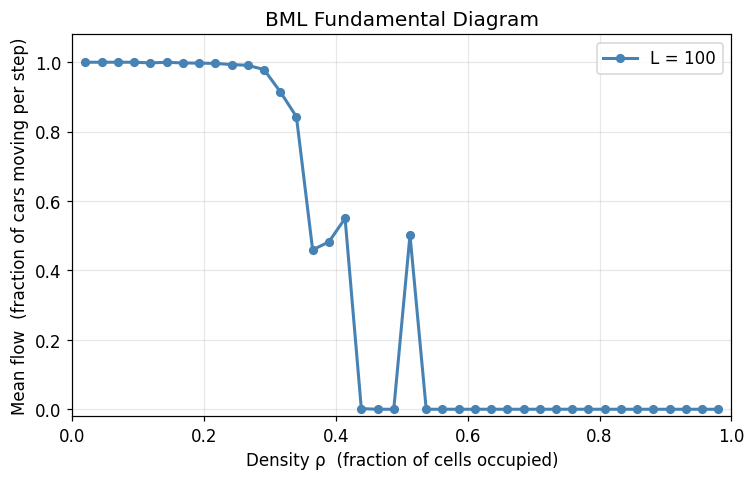

In [30]:
# ── Section 3: Fundamental diagram ───────────────────────────────────────
def run_sweep(L, densities, seed_offset=0, T_warmup=T_WARMUP, T_measure=T_MEASURE):
    '''Run BML at each density; return array of mean flows.'''
    flows = np.zeros(len(densities))
    for i, rho in enumerate(densities):
        sim      = BML(L=L, density=rho, r_horiz=0.5, seed=seed_offset + i)
        sim.warmup(T_warmup)
        flows[i] = sim.run(T_measure)
    return flows


densities_100 = np.linspace(0.02, 0.98, 40)
flows_100     = run_sweep(L=100, densities=densities_100)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(densities_100, flows_100, 'o-', color='steelblue', lw=2, ms=5, label='L = 100')
ax.set_xlabel('Density \u03c1  (fraction of cells occupied)')
ax.set_ylabel('Mean flow  (fraction of cars moving per step)')
ax.set_title('BML Fundamental Diagram')
ax.set_xlim(0, 1)
ax.set_ylim(-0.02, 1.08)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## Section 4: Phase Transition Analysis

The sharpness of the transition is a **finite-size effect**: for small $L$,
fluctuations in the initial placement smear the drop; as $L \to \infty$
the curve converges to a step function.

We locate the critical density $\rho_c$ from the peak of $-\mathrm{d}\phi/\mathrm{d}\rho$
(the susceptibility), analogous to finding a phase transition in statistical mechanics.

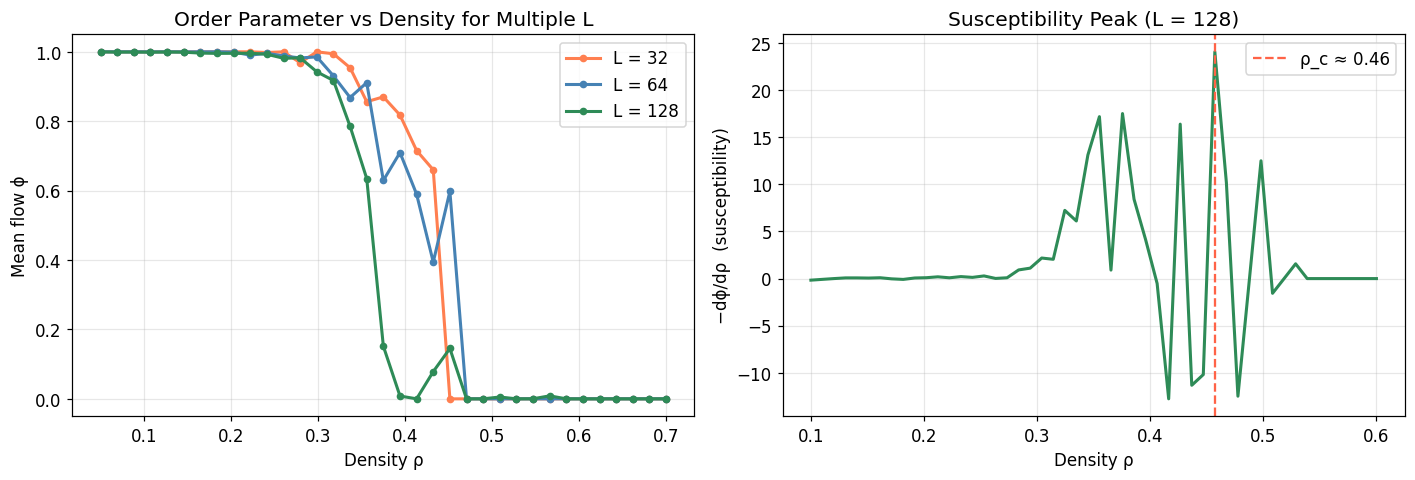

Estimated critical density ρ_c ≈ 0.457  (L = 128)


In [31]:
# ── Section 4: Phase transition analysis ─────────────────────────────────
sizes_pt  = [32, 64, 128]
cols_pt   = ['coral', 'steelblue', 'seagreen']
rhos_pt   = np.linspace(0.05, 0.70, 35)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

fd_by_size_pt = {}
for L_val, col in zip(sizes_pt, cols_pt):
    phi = run_sweep(L=L_val, densities=rhos_pt)
    fd_by_size_pt[L_val] = phi
    axes[0].plot(rhos_pt, phi, 'o-', color=col, lw=2, ms=4, label=f'L = {L_val}')

axes[0].set_xlabel('Density \u03c1')
axes[0].set_ylabel('Mean flow \u03d5')
axes[0].set_title('Order Parameter vs Density for Multiple L')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Susceptibility peak — locate rho_c from L = 128
rhos_fine = np.linspace(0.10, 0.60, 50)
phi_fine  = run_sweep(L=128, densities=rhos_fine)
dphi      = -np.gradient(phi_fine, rhos_fine)
rho_c     = float(rhos_fine[np.argmax(dphi)])

axes[1].plot(rhos_fine, dphi, color='seagreen', lw=2)
axes[1].axvline(rho_c, color='tomato', ls='--', lw=1.5, label=f'\u03c1_c \u2248 {rho_c:.2f}')
axes[1].set_xlabel('Density \u03c1')
axes[1].set_ylabel('\u2212d\u03d5/d\u03c1  (susceptibility)')
axes[1].set_title('Susceptibility Peak (L = 128)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f'Estimated critical density \u03c1_c \u2248 {rho_c:.3f}  (L = 128)')

## Section 5: Grid Snapshots

Visualising the grid state after warmup reveals the three regimes directly:

| Regime | What to look for |
|---|---|
| **Free flow** ($\rho = 0.10$) | Sparse, well-mixed cars; few clusters |
| **Critical** ($\rho \approx \rho_c$) | Self-organised **diagonal stripe patterns** |
| **Gridlock** ($\rho = 0.50$) | Dense, frozen configuration; no car can advance |

The stripe patterns at the critical density are a form of **self-organisation**:
cars of each type spontaneously segregate into bands that allow partial mutual passage.

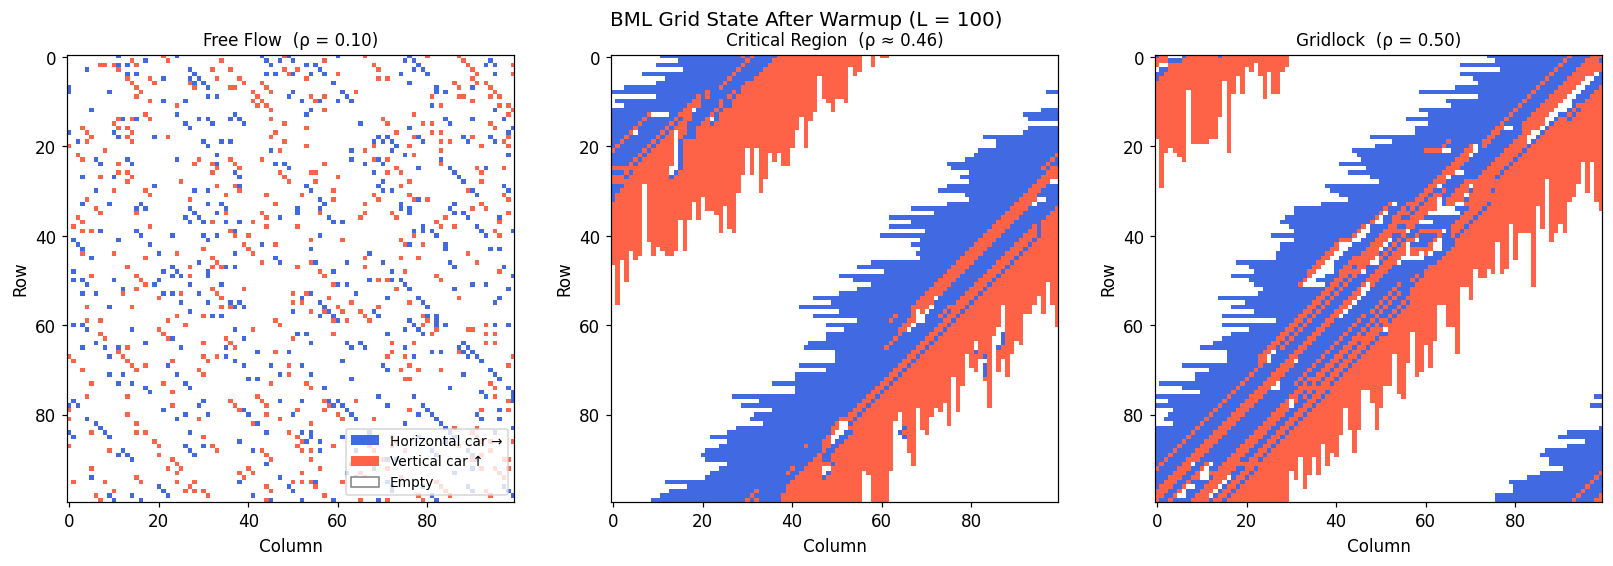

In [32]:
# ── Section 5: Grid snapshots ─────────────────────────────────────────────
cmap_bml = mcolors.ListedColormap(['white', 'royalblue', 'tomato'])
norm_bml = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap_bml.N)

snap_scenarios = [
    (0.10, f'Free Flow  (\u03c1 = 0.10)'),
    (rho_c, f'Critical Region  (\u03c1 \u2248 {rho_c:.2f})'),
    (0.50, 'Gridlock  (\u03c1 = 0.50)'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
legend_elems = [
    Patch(facecolor='royalblue', label='Horizontal car \u2192'),
    Patch(facecolor='tomato',    label='Vertical car \u2191'),
    Patch(facecolor='white', edgecolor='grey', label='Empty'),
]

for ax, (rho, title) in zip(axes, snap_scenarios):
    sim  = BML(L=100, density=rho, r_horiz=0.5, seed=7)
    sim.warmup(T_WARMUP)
    snap = sim.get_snapshot()
    ax.imshow(snap, cmap=cmap_bml, norm=norm_bml, interpolation='nearest')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Column')
    ax.set_ylabel('Row')

axes[0].legend(handles=legend_elems, loc='lower right', fontsize=9)
fig.suptitle('BML Grid State After Warmup (L = 100)', fontsize=13)
plt.tight_layout()
plt.show()

## Section 6: Space–Time Diagrams

We track the binary occupancy of a fixed row ($y = L/2$) over time.

- **Rows** = time steps (top = early, bottom = later).
- **Columns** = road position (left = cell 0, right = cell $L-1$).
- **Black pixel** = occupied (any car type); **white** = empty.

| Panel | Expected pattern |
|---|---|
| Free flow | Row mostly empty; cars pass through quickly |
| Critical | Intermittent clusters; jams form and dissolve |
| Gridlock | Row freezes after brief transient; completely black |

Unlike NaSch space-time diagrams, there are no diagonal backward-propagating
stop-and-go waves — gridlock here is total and irreversible.

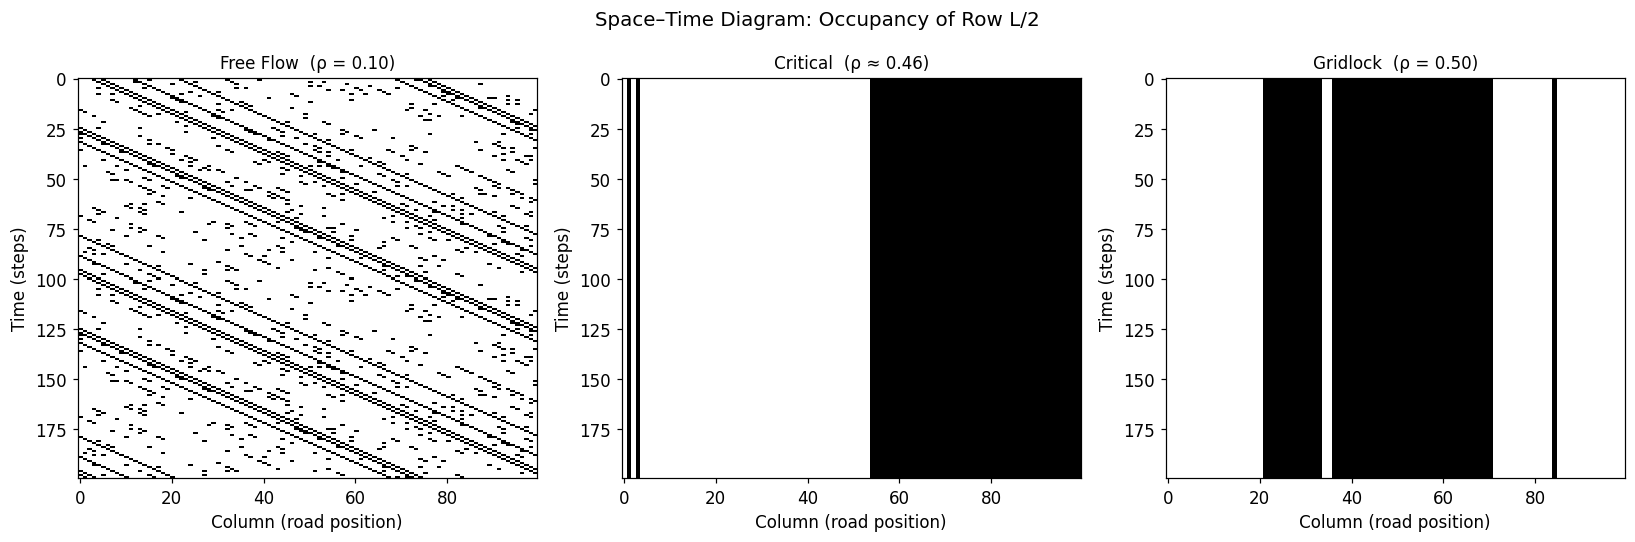

In [33]:
# ── Section 6: Space-time diagrams ───────────────────────────────────────
def record_spacetime(rho, L=100, T_warmup=T_WARMUP, T_record=200):
    sim    = BML(L=L, density=rho, r_horiz=0.5, seed=7)
    sim.warmup(T_warmup)
    row    = L // 2
    frames = np.zeros((T_record, L), dtype=np.int8)
    for t in range(T_record):
        sim.step()
        frames[t] = (sim.grid[row] > 0).astype(np.int8)
    return frames


st_scenarios = [
    (0.10, 'Free Flow  (\u03c1 = 0.10)'),
    (rho_c, f'Critical  (\u03c1 \u2248 {rho_c:.2f})'),
    (0.50, 'Gridlock  (\u03c1 = 0.50)'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (rho, title) in zip(axes, st_scenarios):
    frames = record_spacetime(rho)
    ax.imshow(frames, cmap='binary', interpolation='nearest', aspect='auto')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Column (road position)')
    ax.set_ylabel('Time (steps)')

fig.suptitle('Space\u2013Time Diagram: Occupancy of Row L/2', fontsize=13)
plt.tight_layout()
plt.show()

## Section 8: Summary

### Key Findings

1. **Sharp phase transition**: unlike the NaSch smooth hump, BML shows an abrupt
   drop in flow at $\rho_c \approx 0.32$ (L = 100).  Above this density the system
   reaches gridlock — an absorbing state it cannot escape.

2. **No randomness required**: congestion is entirely deterministic, driven by
   geometric frustration between the two traffic streams.

3. **Self-organised stripe patterns**: near $\rho_c$, cars spontaneously segregate
   into diagonal bands allowing partial mutual passage.

4. **Finite-size effects**: the transition sharpens monotonically with $L$.
   Larger grids converge toward the theoretical step function.

5. **Traffic lights**: signalised intersections alter the critical density and can
   either improve or worsen flow depending on the cycle length relative to the
   natural rhythm of the BML dynamics.

See `biham_sensitivity.ipynb` for parameter sensitivity analysis (car type ratio,
system size effects).

## Section 7: Traffic Lights Extension

### `BMLWithLights` — Signalised Intersections on a 2-D Grid

In the standard BML model the two car streams compete without any coordination.
Adding **traffic lights** at a set of intersection cells introduces external timing:

- During the **horizontal green** phase ($t_H$ steps), horizontal cars may pass through
  intersection cells; vertical cars are blocked at them.
- During the **vertical green** phase ($t_V$ steps), the roles reverse.

This is different from the NaSch traffic-light model (1-D blocking) because in 2-D
both streams need to *share* the same cells — the light resolves the conflict.

### Implementation

`BMLWithLights` subclasses `BML` and overrides the two movement methods:
when a car's target cell is a **red-phase intersection**, the move is suppressed
even if the target is otherwise empty.

### Experiments

1. **Effect on flow**: compare fundamental diagrams with and without lights.
2. **Cycle length**: sweeping $T_\text{cycle}$ shows an optimal cadence that
   minimises mutual blocking near $\rho_c$.
3. **Grid snapshot**: see how intersection cells break up the stripe patterns
   that form at the critical density.

In [34]:
# ── Section 7: BMLWithLights ──────────────────────────────────────────────
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

class BMLWithLights(BML):
    '''
    BML model extended with traffic lights at a grid of intersection cells.

    Light schedule (per timestep t):
      phase = t % T_cycle
      if phase < T_green_h  -> horizontal green, vertical red
      else                  -> vertical green, horizontal red

    Intersection cells form a regular n_lights x n_lights sub-grid
    spaced evenly across the L x L domain.
    '''

    def __init__(self, L, density, n_lights=4, T_cycle=20, T_green_h=None,
                 r_horiz=0.5, seed=None):
        super().__init__(L=L, density=density, r_horiz=r_horiz, seed=seed)
        self.n_lights   = n_lights
        self.T_cycle    = T_cycle
        self.T_green_h  = T_green_h if T_green_h is not None else T_cycle // 2
        self.t          = 0

        # intersection positions: evenly spaced
        spacing = L // (n_lights + 1)
        idx     = np.array([spacing * (i + 1) for i in range(n_lights)])
        # all (row, col) pairs that are intersections
        self.light_rows = idx
        self.light_cols = idx
        # boolean mask for fast lookup
        self._mask = np.zeros((L, L), dtype=bool)
        for r in idx:
            for c in idx:
                self._mask[r, c] = True

    def _horiz_green(self):
        return self.t % self.T_cycle < self.T_green_h

    def _move_horizontal(self):
        '''Horizontal: blocked at intersection cols when vertical is green.'''
        target = np.roll(self.grid, -1, axis=1)
        can_move = (self.grid == 1) & (target == 0)
        if not self._horiz_green():
            # block horizontal cars whose *target* cell is an intersection
            target_is_intersection = np.roll(self._mask, -1, axis=1)
            can_move &= ~target_is_intersection
        n_moved = int(can_move.sum())
        if n_moved:
            g = self.grid.copy()
            g[can_move] = 0
            g[np.roll(can_move, 1, axis=1)] = 1
            self.grid = g
        return n_moved

    def _move_vertical(self):
        '''Vertical: blocked at intersection rows when horizontal is green.'''
        target = np.roll(self.grid, 1, axis=0)
        can_move = (self.grid == 2) & (target == 0)
        if self._horiz_green():
            # block vertical cars whose *target* cell is an intersection
            target_is_intersection = np.roll(self._mask, -1, axis=0)
            can_move &= ~target_is_intersection
        n_moved = int(can_move.sum())
        if n_moved:
            g = self.grid.copy()
            g[can_move] = 0
            g[np.roll(can_move, -1, axis=0)] = 2
            self.grid = g
        return n_moved

    def step(self):
        n_total = int((self.grid > 0).sum())
        moved_h = self._move_horizontal()
        moved_v = self._move_vertical()
        self.t += 1
        return (moved_h + moved_v) / max(n_total, 1)


# ── Quick sanity check ────────────────────────────────────────────────────
sim_tl = BMLWithLights(L=20, density=0.3, n_lights=2, T_cycle=10, seed=0)
print('BMLWithLights defined.')
print(f'  Intersection cells: {[(r,c) for r in sim_tl.light_rows for c in sim_tl.light_cols]}')
print(f'  T_cycle={sim_tl.T_cycle}, T_green_h={sim_tl.T_green_h}')

BMLWithLights defined.
  Intersection cells: [(np.int64(6), np.int64(6)), (np.int64(6), np.int64(12)), (np.int64(12), np.int64(6)), (np.int64(12), np.int64(12))]
  T_cycle=10, T_green_h=5


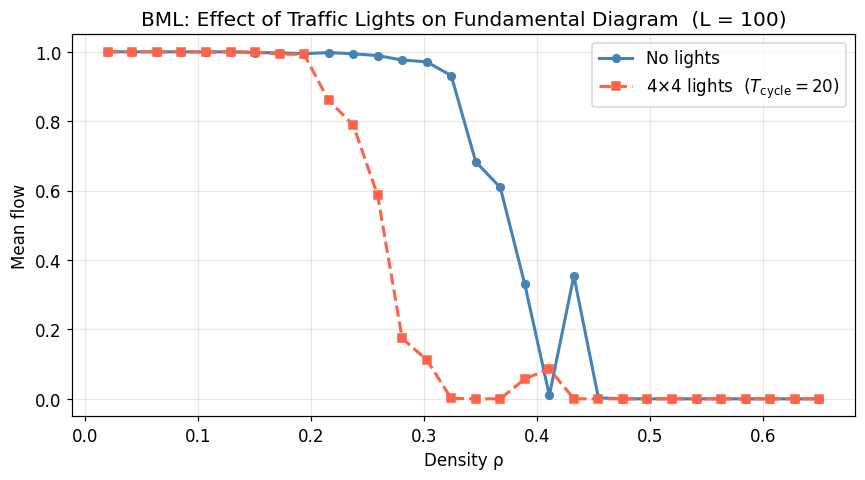

In [35]:
# ── 7a: Fundamental diagram — with vs without lights ─────────────────────
def run_sweep_lights(L, densities, n_lights=4, T_cycle=20,
                     seed_offset=0, T_warmup=T_WARMUP, T_measure=T_MEASURE):
    flows = np.zeros(len(densities))
    for i, rho in enumerate(densities):
        sim = BMLWithLights(L=L, density=rho, n_lights=n_lights,
                            T_cycle=T_cycle, seed=seed_offset + i)
        sim.warmup(T_warmup)
        flows[i] = sim.run(T_measure)
    return flows


rhos_fd   = np.linspace(0.02, 0.65, 30)
flows_no  = run_sweep(L=100, densities=rhos_fd)           # no lights (from BML base)
flows_tl  = run_sweep_lights(L=100, densities=rhos_fd,
                              n_lights=4, T_cycle=20)      # 4x4 intersection grid

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(rhos_fd, flows_no, 'o-', color='steelblue', lw=2, ms=5, label='No lights')
ax.plot(rhos_fd, flows_tl, 's--', color='tomato',    lw=2, ms=5, label='4×4 lights  ($T_\\mathrm{cycle}=20$)')
ax.set_xlabel('Density \u03c1')
ax.set_ylabel('Mean flow')
ax.set_title('BML: Effect of Traffic Lights on Fundamental Diagram  (L = 100)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

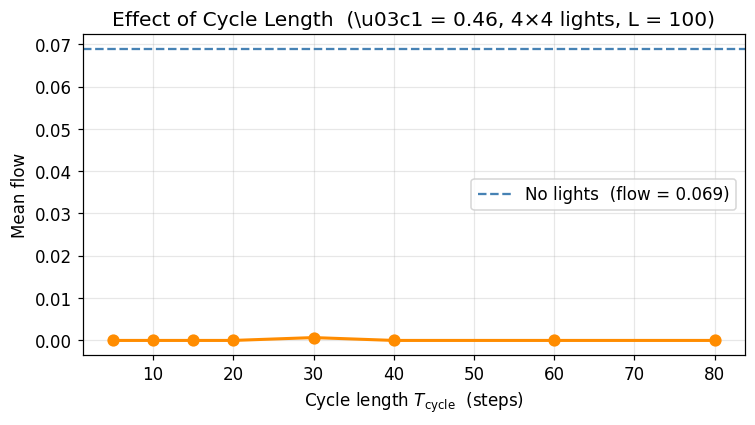

In [36]:
# ── 7b: Cycle length sweep at rho_c ───────────────────────────────────────
T_cycles  = [5, 10, 15, 20, 30, 40, 60, 80]
flows_cyc = []
for T_c in T_cycles:
    sim = BMLWithLights(L=100, density=rho_c, n_lights=4, T_cycle=T_c, seed=1)
    sim.warmup(T_WARMUP)
    flows_cyc.append(sim.run(T_MEASURE))

# baseline: no lights at same density
sim_base = BML(L=100, density=rho_c, seed=1)
sim_base.warmup(T_WARMUP)
flow_base = sim_base.run(T_MEASURE)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(T_cycles, flows_cyc, 'o-', color='darkorange', lw=2, ms=7)
ax.axhline(flow_base, color='steelblue', ls='--', lw=1.5,
           label=f'No lights  (flow = {flow_base:.3f})')
ax.set_xlabel('Cycle length $T_\\mathrm{cycle}$  (steps)')
ax.set_ylabel('Mean flow')
ax.set_title(f'Effect of Cycle Length  (\\u03c1 = {rho_c:.2f}, 4\u00d74 lights, L = 100)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

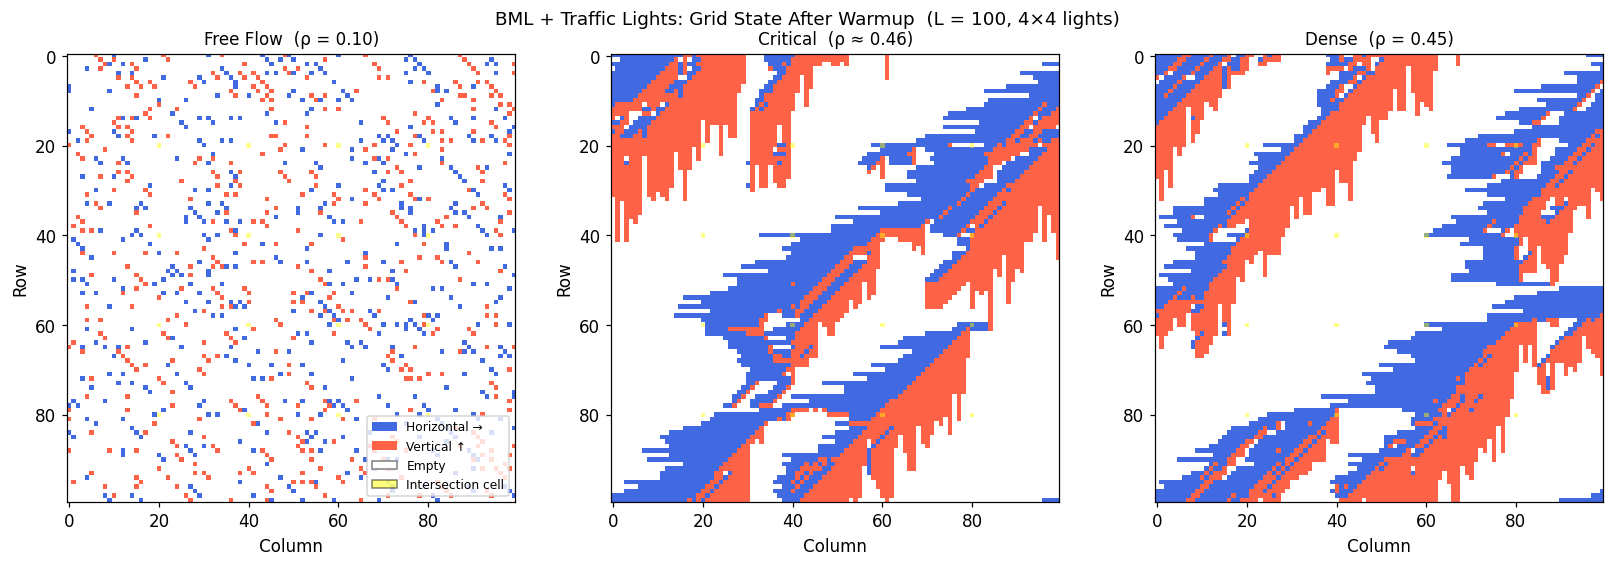

In [37]:
# ── 7c: Grid snapshots with intersection overlay ──────────────────────────
cmap_bml = mcolors.ListedColormap(['white', 'royalblue', 'tomato'])
norm_bml = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap_bml.N)
legend_elems = [
    Patch(facecolor='royalblue', label='Horizontal \u2192'),
    Patch(facecolor='tomato',    label='Vertical \u2191'),
    Patch(facecolor='white', edgecolor='grey', label='Empty'),
    Patch(facecolor='yellow', edgecolor='black', alpha=0.5, label='Intersection cell'),
]

snap_scenarios_tl = [
    (0.10, 'Free Flow  (\u03c1 = 0.10)'),
    (rho_c, f'Critical  (\u03c1 \u2248 {rho_c:.2f})'),
    (0.45, 'Dense  (\u03c1 = 0.45)'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (rho, title) in zip(axes, snap_scenarios_tl):
    sim = BMLWithLights(L=100, density=rho, n_lights=4, T_cycle=20, seed=7)
    sim.warmup(T_WARMUP)
    snap = sim.grid.copy()
    ax.imshow(snap, cmap=cmap_bml, norm=norm_bml, interpolation='nearest')
    # overlay intersection grid as yellow marks
    for r in sim.light_rows:
        for c in sim.light_cols:
            ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1,
                                       linewidth=0, facecolor='yellow', alpha=0.45))
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Column')
    ax.set_ylabel('Row')

axes[0].legend(handles=legend_elems, loc='lower right', fontsize=8)
fig.suptitle('BML + Traffic Lights: Grid State After Warmup  (L = 100, 4\u00d74 lights)',
             fontsize=12)
plt.tight_layout()
plt.show()

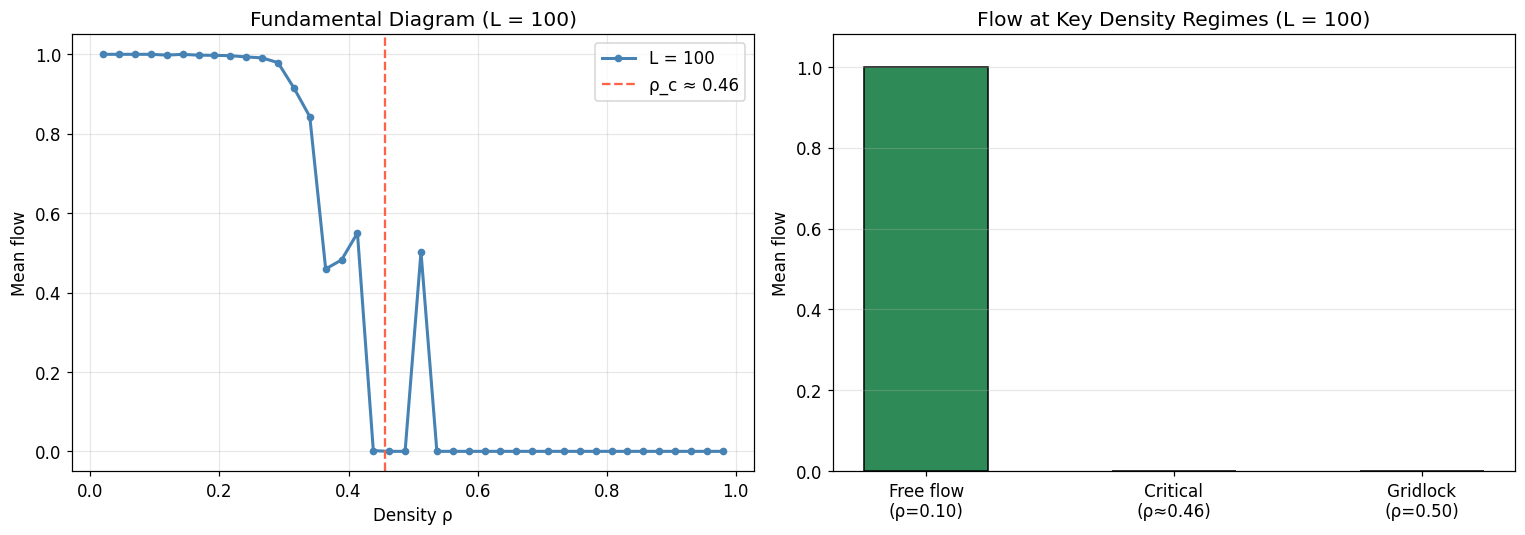


Summary:
  Free flow (ρ=0.10)              flow = 0.9998
  Critical (ρ≈0.46)               flow = 0.0000
  Gridlock (ρ=0.50)               flow = 0.0000


In [38]:
# ── Section 7: Summary plots ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: fundamental diagram from Section 3
axes[0].plot(densities_100, flows_100, 'o-', color='steelblue', lw=2, ms=4, label='L = 100')
axes[0].axvline(rho_c, color='tomato', ls='--', lw=1.5, label=f'\u03c1_c \u2248 {rho_c:.2f}')
axes[0].set_xlabel('Density \u03c1')
axes[0].set_ylabel('Mean flow')
axes[0].set_title('Fundamental Diagram (L = 100)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: bar chart of flow in three key regimes (L = 100)
regime_rhos   = [0.10, rho_c, 0.50]
regime_labels = [
    'Free flow\n(\u03c1=0.10)',
    f'Critical\n(\u03c1\u2248{rho_c:.2f})',
    'Gridlock\n(\u03c1=0.50)',
]
regime_flows = []
for i, rho in enumerate(regime_rhos):
    sim = BML(L=100, density=rho, r_horiz=0.5, seed=99 + i)
    sim.warmup(T_WARMUP)
    regime_flows.append(sim.run(T_MEASURE))

bar_cols = ['seagreen', 'goldenrod', 'tomato']
axes[1].bar(regime_labels, regime_flows, color=bar_cols, edgecolor='black', width=0.5)
axes[1].set_ylabel('Mean flow')
axes[1].set_ylim(0, 1.08)
axes[1].set_title('Flow at Key Density Regimes (L = 100)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print('\nSummary:')
for lbl, f in zip(regime_labels, regime_flows):
    print(f'  {lbl.replace(chr(10)," "):30s}  flow = {f:.4f}')